## Imports

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import KNNImputer
from sklearn.model_selection import cross_val_score, KFold
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [4]:
# 1. Read the data
df = pd.read_csv('Video_Games.csv')

# Separate the target variable (Global_Sales) so that it does not negatively affect the imputation process (Data Leakage)
# If the target variable contains NaN values, those rows are usually dropped in machine learning,
# but since removing rows is not allowed, we also fill it using KNN.
target_col = 'Global_Sales'

# 2. Identify numerical and categorical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. Handle missing values for categorical data
# Strategy: fill based on probability distribution (preserving variance and statistical distribution)
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        # Calculate the probability of each category
        probs = df[col].value_counts(normalize=True)
        # Find the indices of missing values
        missing_indices = df[col][df[col].isnull()].index
        # Randomly choose from categories based on the calculated probabilities
        imputed_values = np.random.choice(probs.index, size=len(missing_indices), p=probs.values)
        # Replace missing values
        df.loc[missing_indices, col] = imputed_values

# 4. Handle missing values for numerical data
# Strategy: use the KNNImputer model
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')

# Apply the imputer to numerical columns
df[num_cols] = knn_imputer.fit_transform(df[num_cols])

# Final check
print("Number of missing values after the operation:")
print(df.isnull().sum())


Number of missing values after the operation:
Name               0
Platform           0
Year_of_Release    0
Genre              0
Publisher          0
NA_Sales           0
EU_Sales           0
JP_Sales           0
Other_Sales        0
Global_Sales       0
Critic_Score       0
Critic_Count       0
User_Score         0
User_Count         0
Developer          0
Rating             0
dtype: int64


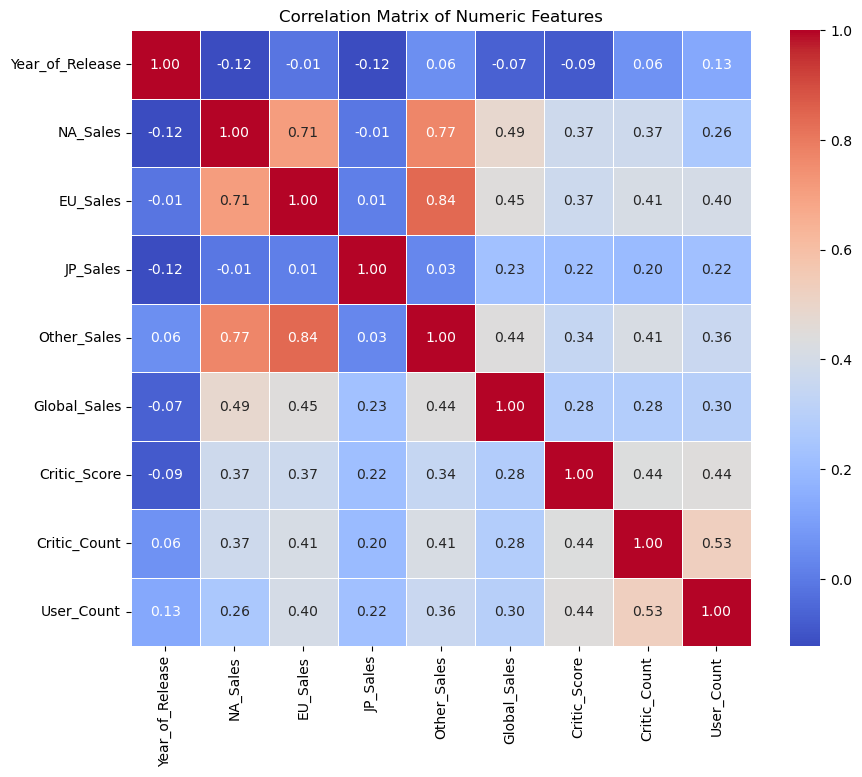


Correlation with Global_Sales:
Global_Sales       1.000000
NA_Sales           0.485795
EU_Sales           0.447237
Other_Sales        0.441895
User_Count         0.295166
Critic_Count       0.284421
Critic_Score       0.280307
JP_Sales           0.227421
Year_of_Release   -0.069118
Name: Global_Sales, dtype: float64


In [5]:
# Assume the dataframe df from the previous step is ready with imputed values
target_col = 'Global_Sales'

# ==========================================
# 1-2: High Cardinality Categorical Variables
# ==========================================
high_cardinality_cols = ['Publisher', 'Name']
threshold = 0.01  # 1 percent threshold

for col in high_cardinality_cols:
    if col in df.columns:
        # Calculate the relative frequency of each category
        frequencies = df[col].value_counts(normalize=True)
        # Identify categories that are below the threshold
        rare_categories = frequencies[frequencies < threshold].index
        # Replace rare categories with the label 'Other'
        df[col] = df[col].replace(rare_categories, 'Other')

# Apply One-Hot Encoding
df = pd.get_dummies(df, columns=high_cardinality_cols, drop_first=True)


# ==========================================
# 1-3: Outlier Management (IQR) & Scaling
# ==========================================
# List of numerical columns (independent of the target variable so that the target is not manipulated)
num_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if target_col in num_features:
    num_features.remove(target_col)

# Handle outliers using the IQR-based clipping method
for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    # Clip values instead of removing rows
    df[col] = np.clip(df[col], lower_bound, upper_bound)

# Scale the data
scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])


# ==========================================
# 2: Feature Selection & EDA (Correlation)
# ==========================================
# Compute the correlation matrix only for numerical columns
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Display the correlation matrix (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

# Display the correlation of features with the target variable
if target_col in corr_matrix.columns:
    print(f"\nCorrelation with {target_col}:")
    print(corr_matrix[target_col].sort_values(ascending=False))


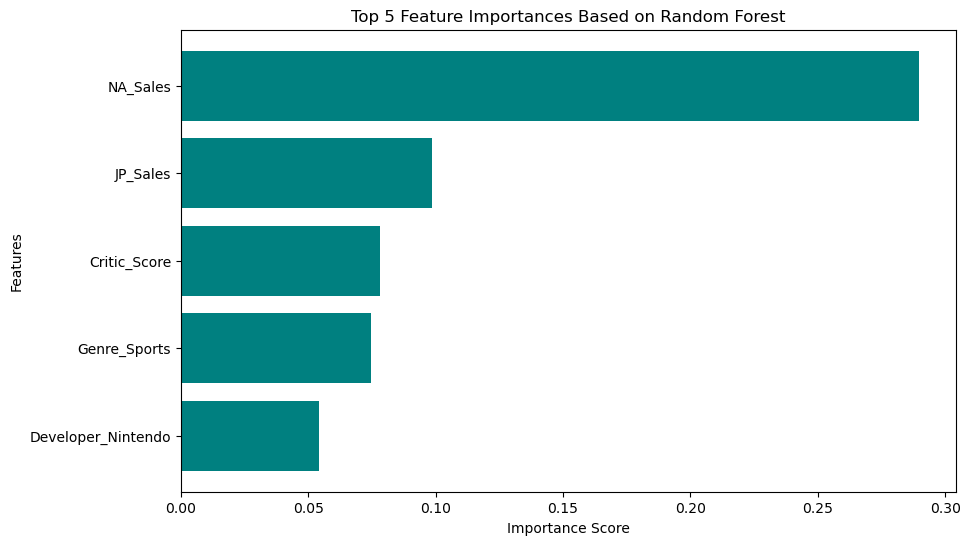

Top 5 Features:
                 Feature  Importance
1               NA_Sales    0.289679
3               JP_Sales    0.098684
5           Critic_Score    0.077949
70          Genre_Sports    0.074670
1186  Developer_Nintendo    0.054102


In [10]:
# Convert all categorical text columns into numerical columns using One-Hot Encoding
# The parameter drop_first=True is used to avoid multicollinearity
df_encoded = pd.get_dummies(df, drop_first=True)

# Separate the features (X) and the target variable (y) from the encoded dataframe
X = df_encoded.drop(columns=['Global_Sales'])
y = df_encoded['Global_Sales']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Create and train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a dataframe for sorting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Select the top 5 features
top_5_features = feature_importance_df.head(5)

# Plot the chart
plt.figure(figsize=(10, 6))
plt.barh(top_5_features['Feature'][::-1], top_5_features['Importance'][::-1], color='teal')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top 5 Feature Importances Based on Random Forest')
plt.show()

print("Top 5 Features:")
print(top_5_features)


In [11]:
# --- 1. Define the model evaluation function ---
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    
    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)
    
    print(f"--- {model_name} ---")
    print(f"Train - MSE: {mse_train:.4f} | RMSE: {rmse_train:.4f} | R2: {r2_train:.4f}")
    print(f"Test  - MSE: {mse_test:.4f} | RMSE: {rmse_test:.4f} | R2: {r2_test:.4f}")
    print("-" * 40)


# --- 2. Select the top 5 features ---
top_5_features = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Year_of_Release']

# Filter the data
X_train_reduced = X_train[top_5_features]
X_test_reduced = X_test[top_5_features]


# --- 3. Train the models and evaluate them ---

# a) Simple linear model
linear_model = LinearRegression()
linear_model.fit(X_train_reduced, y_train)
evaluate_model(linear_model, X_train_reduced, X_test_reduced, y_train, y_test, "Linear Regression")

# Define alpha values for RidgeCV with cross-validation
alphas = np.logspace(-3, 3, 10)

# b) Degree-2 polynomial model with Ridge regularization
poly2_ridge = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    RidgeCV(alphas=alphas, cv=5)
)
poly2_ridge.fit(X_train_reduced, y_train)
evaluate_model(poly2_ridge, X_train_reduced, X_test_reduced, y_train, y_test, "Polynomial (d=2) + RidgeCV")

# c) Degree-3 polynomial model with Ridge regularization
poly3_ridge = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    RidgeCV(alphas=alphas, cv=5)
)
poly3_ridge.fit(X_train_reduced, y_train)
evaluate_model(poly3_ridge, X_train_reduced, X_test_reduced, y_train, y_test, "Polynomial (d=3) + RidgeCV")


--- Linear Regression ---
Train - MSE: 1.2603 | RMSE: 1.1227 | R2: 0.3578
Test  - MSE: 3.2359 | RMSE: 1.7989 | R2: 0.2161
----------------------------------------
--- Polynomial (d=2) + RidgeCV ---
Train - MSE: 1.0585 | RMSE: 1.0288 | R2: 0.4607
Test  - MSE: 2.9488 | RMSE: 1.7172 | R2: 0.2856
----------------------------------------
--- Polynomial (d=3) + RidgeCV ---
Train - MSE: 0.9556 | RMSE: 0.9775 | R2: 0.5131
Test  - MSE: 2.8799 | RMSE: 1.6970 | R2: 0.3023
----------------------------------------


In [ ]:
# --- Hyperparameter search space settings ---
param_bounds = {
    'max_depth': (2, 30),
    'min_samples_split': (2, 20),
    'min_samples_leaf': (1, 20)
}

# --- 1. Define the fitness function ---
def calculate_cost(individual, X, y, penalty_weight=0.1):
    max_depth, min_samples_split, min_samples_leaf = individual
    
    # Build the model with the hyperparameters of the current chromosome
    model = DecisionTreeRegressor(
        max_depth=int(max_depth),
        min_samples_split=int(min_samples_split),
        min_samples_leaf=int(min_samples_leaf),
        random_state=42
    )
    
    # Compute the mean MSE using 5-Fold Cross Validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    # The output of cross_val_score for MSE is negative, so we negate it
    mse_scores = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
    mean_mse = np.mean(mse_scores)
    
    # Add a penalty term to control tree complexity
    penalty = penalty_weight * max_depth
    
    # Total cost (the lower it is, the better the chromosome)
    total_cost = mean_mse + penalty
    return total_cost

# --- 2. Main functions of the genetic algorithm ---

def init_population(pop_size):
    population = []
    for _ in range(pop_size):
        ind = [
            random.randint(*param_bounds['max_depth']),
            random.randint(*param_bounds['min_samples_split']),
            random.randint(*param_bounds['min_samples_leaf'])
        ]
        population.append(ind)
    return population

def crossover(parent1, parent2):
    # Uniform crossover: randomly select each gene from one of the parents
    child = []
    for i in range(len(parent1)):
        if random.random() > 0.5:
            child.append(parent1[i])
        else:
            child.append(parent2[i])
    return child

def mutate(individual, mutation_rate=0.1):
    mutated = individual.copy()
    if random.random() < mutation_rate:
        mutated[0] = random.randint(*param_bounds['max_depth'])
    if random.random() < mutation_rate:
        mutated[1] = random.randint(*param_bounds['min_samples_split'])
    if random.random() < mutation_rate:
        mutated[2] = random.randint(*param_bounds['min_samples_leaf'])
    return mutated

# --- 3. Main loop of the genetic algorithm ---
def genetic_algorithm_tree(X, y, pop_size=20, generations=10, mutation_rate=0.2, penalty_weight=0.1):
    population = init_population(pop_size)
    best_individual = None
    best_cost = float('inf')
    
    for generation in range(generations):
        # Evaluate the entire population
        scored_population = []
        for ind in population:
            cost = calculate_cost(ind, X, y, penalty_weight)
            scored_population.append((cost, ind))
            
            # Record the best solution found so far
            if cost < best_cost:
                best_cost = cost
                best_individual = ind
                
        # Sort the population based on cost (ascending - lower cost is better)
        scored_population.sort(key=lambda x: x[0])
        print(f"Generation {generation+1} | Best Cost (MSE + Penalty): {scored_population[0][0]:.4f} | Params: {scored_population[0][1]}")
        
        # Select the top 50 percent of the population as parents (Truncation Selection)
        top_performers = [ind for cost, ind in scored_population[:pop_size//2]]
        
        # Create the next generation
        new_population = top_performers.copy()  # Keep the best individuals from the previous generation (Elitism)
        
        while len(new_population) < pop_size:
            # Randomly select two parents from the top performers
            p1, p2 = random.sample(top_performers, 2)
            child = crossover(p1, p2)
            child = mutate(child, mutation_rate)
            new_population.append(child)
            
        population = new_population
        
    return best_individual, best_cost

# --- 4. How to use it (run on the data) ---
# Assume that X_train_reduced and y_train are available from the previous steps
best_params, best_loss = genetic_algorithm_tree(X_train_reduced, y_train, pop_size=20, generations=10, penalty_weight=0.5)

print("\n--- Final Result ---")
print(f"Best Hyperparameters (max_depth, min_samples_split, min_samples_leaf): {best_params}")


C:\Users\Ehadish\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.8515 - mae: 0.4128 - val_loss: 3.5757 - val_mae: 0.3450
Epoch 2/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.3813 - mae: 0.3287 - val_loss: 3.2269 - val_mae: 0.3250
Epoch 3/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.2101 - mae: 0.3147 - val_loss: 3.0816 - val_mae: 0.3134
Epoch 4/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.1511 - mae: 0.3028 - val_loss: 3.0121 - val_mae: 0.3003
Epoch 5/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.0977 - mae: 0.2935 - val_loss: 2.9587 - val_mae: 0.2967
Epoch 6/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.0703 - mae: 0.2949 - val_loss: 2.9193 - val_mae: 0.2905
Epoch 7/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.0161 - mae: 0.2875 - val_loss: 2.8826 - val_mae: 0.2893
Epoch 8/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.0039 - mae: 0.2876 - val_loss: 2.8536 - val_mae: 0.2863
Epoch 9/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/

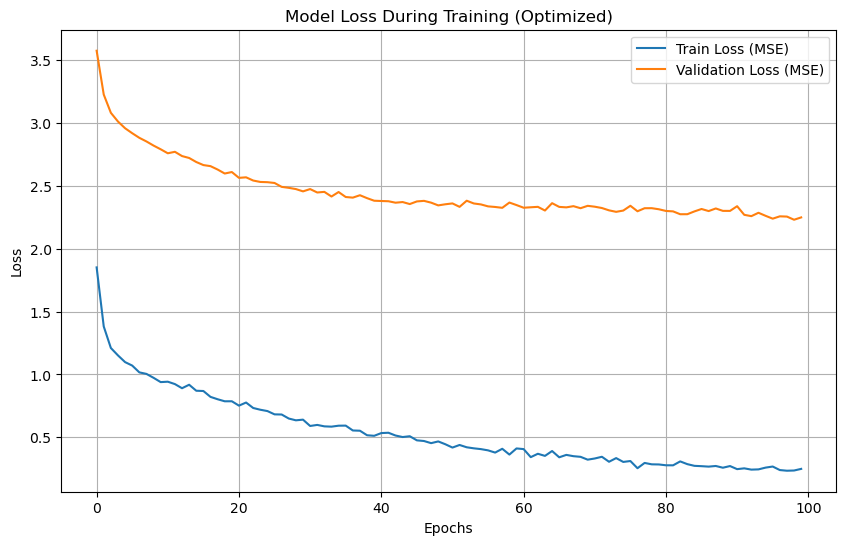

In [12]:
# 1. Build the MLP model architecture
model = Sequential()

# First hidden layer with ReLU activation function
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.2))  # Dropout to prevent overfitting

# Second hidden layer
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# Output layer for regression (without activation function)
model.add(Dense(1))

# 2. Set the learning rate and compile the model
# Reduce the learning rate to prevent severe oscillation
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# 3. Train the model
# Increase batch_size to 64 for more stable validation loss
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=64,
    verbose=1
)

# 4. Plot the loss curve to examine the fitting behavior
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Model Loss During Training (Optimized)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


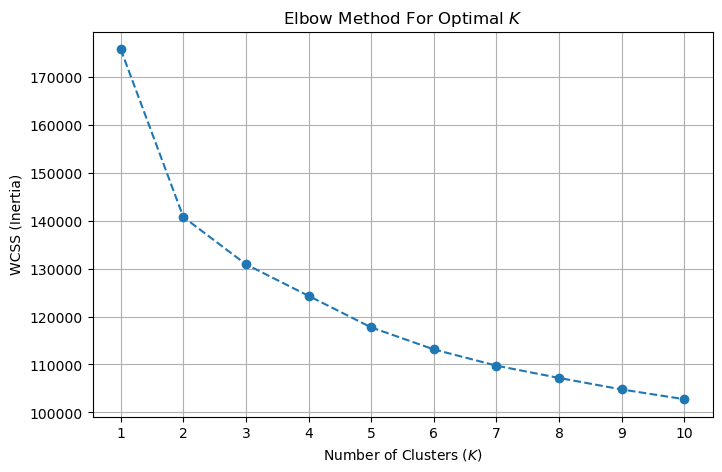

Cluster Centers (Mean of features per cluster):
         Year_of_Release  NA_Sales  EU_Sales  JP_Sales  Other_Sales
Cluster                                                            
0              -0.362423  1.158824  1.033980 -0.379542     1.120307
1               0.336804  1.414192  1.690790  0.550050     1.643340
2               0.093511 -0.657451 -0.532211  0.854511    -0.549866
3              -0.010804 -0.393123 -0.497027 -0.542045    -0.505284


In [14]:
# 1. Find the optimal K using the Elbow Method
wcss = []  # Within-Cluster Sum of Squares
K_range = range(1, 11)

# Train K-Means for different K values on the training data (which has already been scaled)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_train)
    wcss.append(kmeans_temp.inertia_)

# Plot the Elbow chart
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal $K$')
plt.xlabel('Number of Clusters ($K$)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

# Assuming that based on the chart, the elbow point is at K=3 or K=4.
# Here, we choose K=4 as the optimal number of clusters.
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Predict clusters for the training and test data
train_clusters = kmeans.fit_predict(X_train)
test_clusters = kmeans.predict(X_test)

# Interpret the business logic (display the mean of features in each cluster)
# Note: For more accurate interpretation, it is better to do this on the data before scaling,
# but here we create a DataFrame from the training data as an example.
df_train_clusters = pd.DataFrame(X_train)  # Assuming X_train is a NumPy array
df_train_clusters['Cluster'] = train_clusters
cluster_centers = df_train_clusters.groupby('Cluster').mean()
print("Cluster Centers (Mean of features per cluster):")
print(cluster_centers.iloc[:, :5])  # Print the first 5 features to avoid clutter


In [15]:
# 1. Convert cluster labels to One-Hot Encoding
# drop='first' is used to avoid multicolation (Multicollinearity)
encoder = OneHotEncoder(drop='first', sparse_output=False)

# Reshape the data into a column and apply OHE
train_clusters_ohe = encoder.fit_transform(train_clusters.reshape(-1, 1))
test_clusters_ohe = encoder.transform(test_clusters.reshape(-1, 1))

# 2. Add the new features (clusters) to the original data
X_train_enriched = np.hstack((X_train, train_clusters_ohe))
X_test_enriched = np.hstack((X_test, test_clusters_ohe))

# 3. Train the KNN Regression model on the enriched data
knn_reg = KNeighborsRegressor(n_neighbors=5, weights='distance')
knn_reg.fit(X_train_enriched, y_train)

# 4. Predict and evaluate
y_pred_knn = knn_reg.predict(X_test_enriched)

mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("--- KNN Regression with Clustering Features ---")
print(f"MSE:  {mse_knn:.4f}")
print(f"RMSE: {rmse_knn:.4f}")
print(f"R2:   {r2_knn:.4f}")


--- KNN Regression with Clustering Features ---
MSE:  2.1129
RMSE: 1.4536
R2:   0.4881
